<a href="https://colab.research.google.com/github/nur21horin/macine_learning/blob/main/times_series.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ==============================================================================
# COMPLETE TIME SERIES ANALYSIS PIPELINE (ARIMA & SARIMA)
# ==============================================================================
# Import OS library to check if the CSV file exists locally
import os
# Import numpy library for numeric operations and array manipulation
import numpy as np
# Import pandas library for loading, cleaning, and resampling time series data
import pandas as pd
# Import matplotlib pyplot module for visual plotting and rendering graphs
import matplotlib.pyplot as plt
# Import Augmented Dickey-Fuller test function for stationarity testing
from statsmodels.tsa.stattools import adfuller
# Import KPSS test function to verify stationarity alongside ADF test
from statsmodels.tsa.stattools import kpss
# Import seasonal decomposition module to separate trend, seasonal, residual
from statsmodels.tsa.seasonal import seasonal_decompose
# Import Autocorrelation Function (ACF) plot function
from statsmodels.graphics.tsaplots import plot_acf
# Import Partial Autocorrelation Function (PACF) plot function
from statsmodels.graphics.tsaplots import plot_pacf
# Import standard non-seasonal ARIMA model class
from statsmodels.tsa.arima.model import ARIMA
# Import SARIMAX state-space model class for seasonal time series
from statsmodels.tsa.statespace.sarimax import SARIMAX
# Import Mean Absolute Error metric for evaluating model accuracy
from sklearn.metrics import mean_absolute_error
# Import Mean Squared Error metric for evaluating model variance
from sklearn.metrics import mean_squared_error

In [2]:
# Set plot style for clean visuals across all generated plots
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
# Define default figure width (12 inches) and height (6 inches)
plt.rcParams['figure.figsize'] = (12, 6)

In [3]:
# ------------------------------------------------------------------------------
# 1. DATASET LOADING / FALLBACK CREATION
# ------------------------------------------------------------------------------
# Set filename variable pointing to the uploaded or generated CSV file
csv_file_path = 'timeseries_dataset.csv'

# Check if the dataset CSV file is present in the current working directory
if not os.path.exists(csv_file_path):
    # Print notification that synthetic dataset is being created automatically
    print(f"File '{csv_file_path}' not found. Generating a new CSV file automatically...")
    # Set seed value to 42 so generated random numbers are 100% reproducible
    np.random.seed(42)
    # Generate daily sequence of date timestamps from Jan 1 2021 to Dec 31 2023
    dates = pd.date_range(start='2021-01-01', end='2023-12-31', freq='D')
    # Count total days in generated date sequence
    n_pts = len(dates)
    # Generate linear upward trend values from 50 up to 150
    trend = np.linspace(50, 150, n_pts)
    # Generate annual trigonometric sine-wave seasonal oscillation
    seasonality = 20 * np.sin(2 * np.pi * dates.dayofyear / 365.25)
    # Generate random normally distributed Gaussian noise with std dev of 5
    noise = np.random.normal(0, 5, n_pts)
    # Combine trend, seasonality, and noise into final synthetic values
    y_values = np.round(trend + seasonality + noise, 2)
    # Wrap generated arrays into a pandas DataFrame object
    df_raw = pd.DataFrame({'Date': dates, 'Value': y_values})
    # Save the generated DataFrame into disk as a CSV file
    df_raw.to_csv(csv_file_path, index=False)
    # Confirm successful creation of CSV dataset file
    print(f"Dataset '{csv_file_path}' saved successfully!")

# Load dataset from the CSV file, parsing Date as datetime and setting as index
df = pd.read_csv(csv_file_path, parse_dates=['Date'], index_col='Date')
# Print confirmation message for dataset loading
print("\n--- Raw Dataset Summary ---")
# Display shape (rows, columns) of loaded DataFrame
print(f"Dataset Shape: {df.shape}")
# Print top 5 initial observations from the dataset
print(df.head())

# Resample raw daily data into monthly averages ('MS' = Month Start frequency)
df_monthly = df.resample('MS').mean()
# Print confirmation of resampling operation
print("\n--- Resampled Monthly Dataset Sample ---")
# Print top 5 rows of monthly aggregated series
print(df_monthly.head())

File 'timeseries_dataset.csv' not found. Generating a new CSV file automatically...
Dataset 'timeseries_dataset.csv' saved successfully!

--- Raw Dataset Summary ---
Dataset Shape: (1095, 1)
            Value
Date             
2021-01-01  52.83
2021-01-02  50.09
2021-01-03  54.45
2021-01-04  59.26
2021-01-05  50.91

--- Resampled Monthly Dataset Sample ---
                Value
Date                 
2021-01-01  55.735161
2021-02-01  67.320000
2021-03-01  75.975806
2021-04-01  78.643333
2021-05-01  76.127097


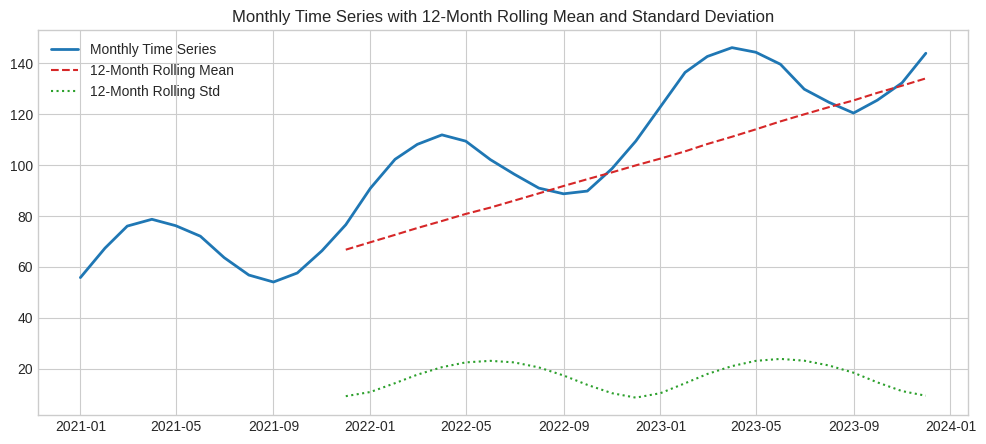

In [4]:
# ------------------------------------------------------------------------------
# 2. EXPLORATORY ANALYSIS & ROLLING STATISTICS
# ------------------------------------------------------------------------------
# Compute 12-month rolling mean to visualize smooth long-term trend line
df_monthly['Rolling_Mean'] = df_monthly['Value'].rolling(window=12).mean()
# Compute 12-month rolling standard deviation to inspect variance stability
df_monthly['Rolling_Std'] = df_monthly['Value'].rolling(window=12).std()

# Initialize visual figure canvas for rolling statistics
plt.figure(figsize=(12, 5))
# Plot actual monthly values in blue solid line
plt.plot(df_monthly['Value'], label='Monthly Time Series', color='#1f77b4', linewidth=2)
# Plot 12-month rolling mean in dashed red line
plt.plot(df_monthly['Rolling_Mean'], label='12-Month Rolling Mean', color='#d62728', linestyle='--')
# Plot 12-month rolling standard deviation in dotted green line
plt.plot(df_monthly['Rolling_Std'], label='12-Month Rolling Std', color='#2ca02c', linestyle=':')
# Set main title header for rolling statistics plot
plt.title('Monthly Time Series with 12-Month Rolling Mean and Standard Deviation', fontsize=12)
# Position legend in upper left corner of axes
plt.legend(loc='upper left')
# Render the created rolling statistics chart on screen
plt.show()

In [5]:
# ------------------------------------------------------------------------------
# 3. STATIONARITY TESTING (ADF & KPSS)
# ------------------------------------------------------------------------------
# Define custom function to run and report ADF and KPSS stationarity tests
def run_stationarity_tests(series, series_title="Original Series"):
    # Print section header banner for stationarity testing
    print(f"\n=== Stationarity Tests: {series_title} ===")
    # Execute Augmented Dickey-Fuller (ADF) test on dropna series
    adf_res = adfuller(series.dropna())
    # Print calculated ADF test statistic rounded to 4 decimals
    print(f"ADF Statistic  : {adf_res[0]:.4f}")
    # Print calculated ADF p-value rounded to 4 decimals
    print(f"ADF p-value    : {adf_res[1]:.4f}")
    # Evaluate ADF p-value against standard 0.05 threshold
    adf_status = "Stationary (Reject H0)" if adf_res[1] < 0.05 else "Non-Stationary (Fail to Reject H0)"
    # Print plain-English conclusion from ADF test
    print(f"ADF Result     : {adf_status}")

    # Execute KPSS test on non-null values with constant regression
    kpss_res = kpss(series.dropna(), regression='c', nlags='auto')
    # Print calculated KPSS test statistic rounded to 4 decimals
    print(f"KPSS Statistic : {kpss_res[0]:.4f}")
    # Print calculated KPSS p-value rounded to 4 decimals
    print(f"KPSS p-value   : {kpss_res[1]:.4f}")
    # Evaluate KPSS p-value against standard 0.05 threshold
    kpss_status = "Stationary (Fail to Reject H0)" if kpss_res[1] > 0.05 else "Non-Stationary (Reject H0)"
    # Print plain-English conclusion from KPSS test
    print(f"KPSS Result    : {kpss_status}")

# Run stationarity check on original un-differenced monthly series
run_stationarity_tests(df_monthly['Value'], "Original Monthly Series")

# Perform 1st-order differencing to remove trend non-stationarity
df_monthly['Value_Diff'] = df_monthly['Value'].diff()
# Run stationarity check on 1st-differenced series to verify stationarity
run_stationarity_tests(df_monthly['Value_Diff'], "1st Differenced Series")


=== Stationarity Tests: Original Monthly Series ===
ADF Statistic  : 0.2082
ADF p-value    : 0.9727
ADF Result     : Non-Stationary (Fail to Reject H0)
KPSS Statistic : 0.7164
KPSS p-value   : 0.0121
KPSS Result    : Non-Stationary (Reject H0)

=== Stationarity Tests: 1st Differenced Series ===
ADF Statistic  : -5.2115
ADF p-value    : 0.0000
ADF Result     : Stationary (Reject H0)
KPSS Statistic : 0.0404
KPSS p-value   : 0.1000
KPSS Result    : Stationary (Fail to Reject H0)


/tmp/ipykernel_2628/2121091878.py:20: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_res = kpss(series.dropna(), regression='c', nlags='auto')


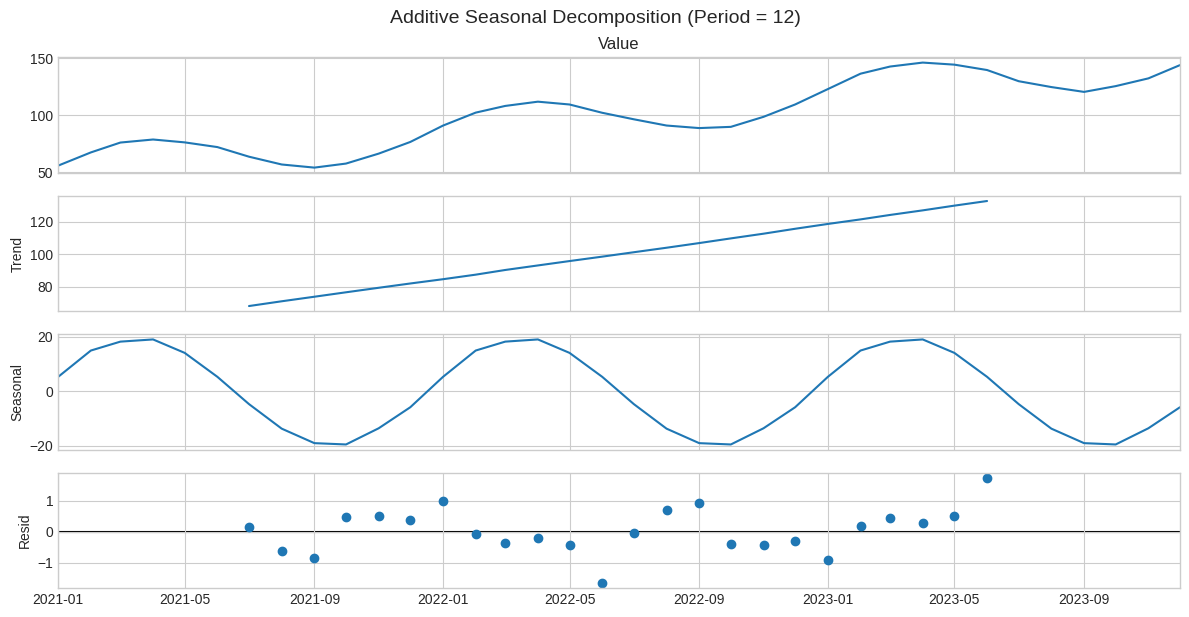

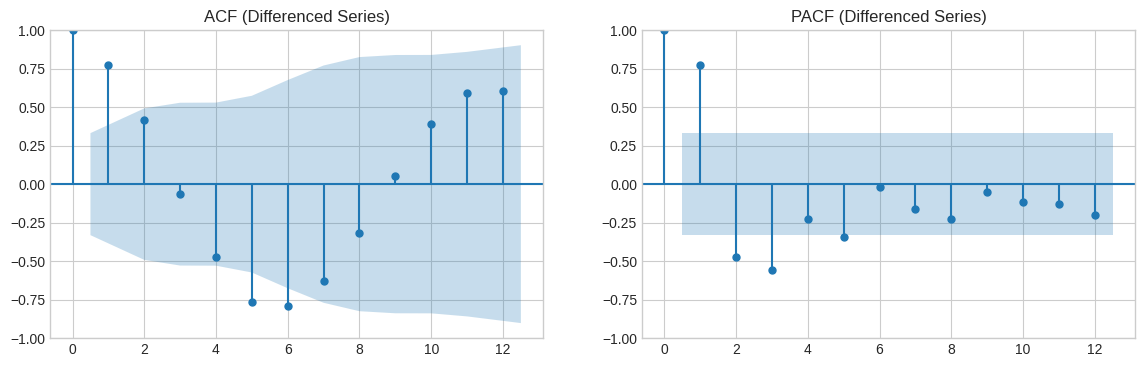

In [6]:
# ------------------------------------------------------------------------------
# 4. TIME SERIES DECOMPOSITION & ACF / PACF ANALYSIS
# ------------------------------------------------------------------------------
# Perform additive seasonal decomposition with period=12 (12 months/year)
decomp = seasonal_decompose(df_monthly['Value'], model='additive', period=12)
# Draw multi-panel decomposition figure (Observed, Trend, Seasonal, Residual)
fig_decomp = decomp.plot()
# Set main title for overall seasonal decomposition figure
fig_decomp.suptitle('Additive Seasonal Decomposition (Period = 12)', fontsize=14, y=1.02)
# Render decomposition figure
plt.show()

# Create subplot figure for side-by-side ACF and PACF plots
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
# Plot ACF on first subplot axis up to 12 lags
plot_acf(df_monthly['Value_Diff'].dropna(), ax=axes[0], lags=12, title='ACF (Differenced Series)')
# Plot PACF on second subplot axis up to 12 lags
plot_pacf(df_monthly['Value_Diff'].dropna(), ax=axes[1], lags=12, title='PACF (Differenced Series)')
# Display ACF and PACF charts side-by-side
plt.show()

In [7]:
# ------------------------------------------------------------------------------
# 5. MODEL TRAINING: ARIMA vs SARIMA
# ------------------------------------------------------------------------------
# Determine row count index corresponding to 80% split boundary
train_size = int(len(df_monthly) * 0.8)
# Slice training dataset containing first 80% of historical data
train = df_monthly['Value'].iloc[:train_size]
# Slice testing dataset containing remaining 20% validation data
test = df_monthly['Value'].iloc[train_size:]

# Print number of training and test months allocated
print(f"\nTrain observations: {len(train)} | Test observations: {len(test)}")

# Initialize non-seasonal ARIMA model with orders p=1, d=1, q=1
model_arima = ARIMA(train, order=(1, 1, 1))
# Fit non-seasonal ARIMA model parameters using maximum likelihood
fit_arima = model_arima.fit()
# Generate point forecasts for test period length using ARIMA
pred_arima = fit_arima.forecast(steps=len(test))

# Initialize seasonal SARIMA model with orders (1,1,1) x (1,1,0,12)
model_sarima = SARIMAX(train, order=(1, 1, 1), seasonal_order=(1, 1, 0, 12))
# Fit seasonal SARIMA model parameters silently (disp=False)
fit_sarima = model_sarima.fit(disp=False)
# Obtain forecast results object including confidence bands
forecast_sarima_obj = fit_sarima.get_forecast(steps=len(test))
# Extract predicted mean forecast values from SARIMA object
pred_sarima = forecast_sarima_obj.predicted_mean
# Extract 95% confidence interval upper and lower limits from SARIMA object
ci_sarima = forecast_sarima_obj.conf_int()


Train observations: 28 | Test observations: 8


=== ARIMA(1,1,1) Metrics ===
MAE  : 22.900
RMSE : 25.074
MAPE : 17.82%

=== SARIMA(1,1,1)x(1,1,0,12) Metrics ===
MAE  : 1.030
RMSE : 1.189
MAPE : 0.78%



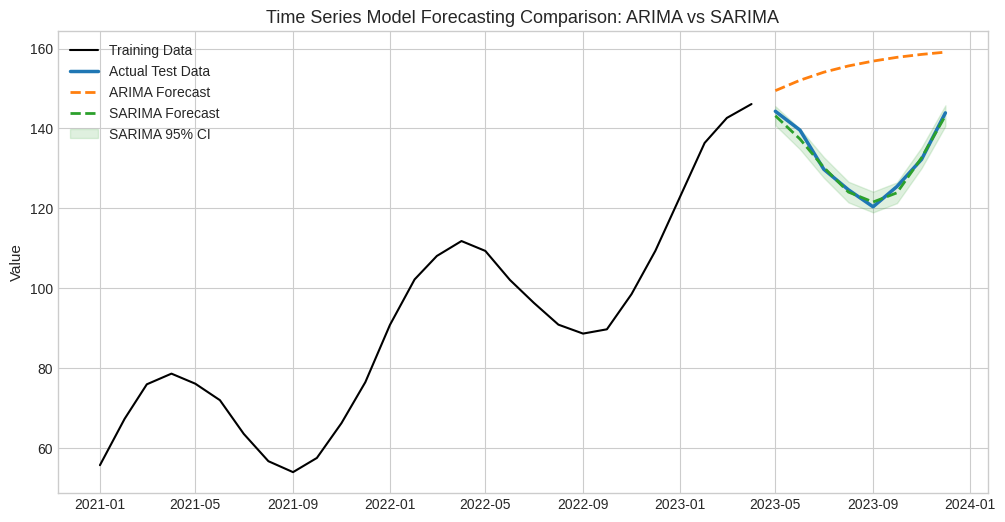

In [8]:
# ------------------------------------------------------------------------------
# 6. PERFORMANCE EVALUATION & FORECAST VISUALIZATION
# ------------------------------------------------------------------------------
# Custom helper function to calculate and display forecast error metrics
def evaluate_model(actual, forecast, model_name):
    # Calculate Mean Absolute Error (MAE)
    mae = mean_absolute_error(actual, forecast)
    # Calculate Root Mean Squared Error (RMSE)
    rmse = np.sqrt(mean_squared_error(actual, forecast))
    # Calculate Mean Absolute Percentage Error (MAPE)
    mape = np.mean(np.abs((actual - forecast) / actual)) * 100
    # Print formatted evaluation metrics
    print(f"=== {model_name} Metrics ===")
    print(f"MAE  : {mae:.3f}")
    print(f"RMSE : {rmse:.3f}")
    print(f"MAPE : {mape:.2f}%\n")

# Run evaluation function for standard non-seasonal ARIMA model
evaluate_model(test, pred_arima, "ARIMA(1,1,1)")
# Run evaluation function for seasonal SARIMA model
evaluate_model(test, pred_sarima, "SARIMA(1,1,1)x(1,1,0,12)")

# Create final forecast visual comparison chart canvas
plt.figure(figsize=(12, 6))
# Plot historical training observations in black line
plt.plot(train.index, train, label='Training Data', color='black', linewidth=1.5)
# Plot actual ground-truth test observations in solid blue line
plt.plot(test.index, test, label='Actual Test Data', color='#1f77b4', linewidth=2.5)
# Plot non-seasonal ARIMA forecasts in dashed orange line
plt.plot(test.index, pred_arima, label='ARIMA Forecast', color='#ff7f0e', linestyle='--', linewidth=2)
# Plot seasonal SARIMA forecasts in dashed green line
plt.plot(test.index, pred_sarima, label='SARIMA Forecast', color='#2ca02c', linestyle='--', linewidth=2)
# Fill light green shaded confidence interval range for SARIMA forecast
plt.fill_between(test.index, ci_sarima.iloc[:, 0], ci_sarima.iloc[:, 1], color='#2ca02c', alpha=0.15, label='SARIMA 95% CI')
# Add main chart header title
plt.title('Time Series Model Forecasting Comparison: ARIMA vs SARIMA', fontsize=13)
# Add y-axis label description
plt.ylabel('Value', fontsize=11)
# Display legend box at top left position
plt.legend(loc='upper left')
# Render final comparison plot on screen
plt.show()